In [1]:
import pandas as pd
from statsbombpy import sb
df_raw = sb.events(match_id= 3869685)

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
df = df_raw.copy(deep = True)

In [4]:
df = df[df['type'] == 'Shot']


df = df[['team', 'player', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type']]

In [5]:
df.head()

,team,player,location,shot_outcome,shot_statsbomb_xg,shot_type
4207,Argentina,Alexis Mac Allister,"[92.4, 30.0]",Saved,0.024542,Open Play
4208,Argentina,Rodrigo Javier De Paul,"[99.2, 47.9]",Blocked,0.062813,Open Play
4209,Argentina,Ángel Fabián Di María Hernández,"[103.1, 34.6]",Off T,0.106801,Open Play
4210,Argentina,Lionel Andrés Messi Cuccittini,"[108.0, 40.0]",Goal,0.783500,Penalty
4211,Argentina,Alexis Mac Allister,"[94.3, 23.5]",Wayward,0.010578,Open Play


In [6]:
df = df[df['shot_type'] != 'Penalty']

df.head()

,team,player,location,shot_outcome,shot_statsbomb_xg,shot_type
4207,Argentina,Alexis Mac Allister,"[92.4, 30.0]",Saved,0.024542,Open Play
4208,Argentina,Rodrigo Javier De Paul,"[99.2, 47.9]",Blocked,0.062813,Open Play
4209,Argentina,Ángel Fabián Di María Hernández,"[103.1, 34.6]",Off T,0.106801,Open Play
4211,Argentina,Alexis Mac Allister,"[94.3, 23.5]",Wayward,0.010578,Open Play
4212,Argentina,Ángel Fabián Di María Hernández,"[111.8, 32.1]",Goal,0.303409,Open Play


In [7]:
df[['x', 'y']] = df['location'].apply(pd.Series)

In [8]:
df.head()

,team,player,location,shot_outcome,shot_statsbomb_xg,shot_type,x,y
4207,Argentina,Alexis Mac Allister,"[92.4, 30.0]",Saved,0.024542,Open Play,92.4,30.0
4208,Argentina,Rodrigo Javier De Paul,"[99.2, 47.9]",Blocked,0.062813,Open Play,99.2,47.9
4209,Argentina,Ángel Fabián Di María Hernández,"[103.1, 34.6]",Off T,0.106801,Open Play,103.1,34.6
4211,Argentina,Alexis Mac Allister,"[94.3, 23.5]",Wayward,0.010578,Open Play,94.3,23.5
4212,Argentina,Ángel Fabián Di María Hernández,"[111.8, 32.1]",Goal,0.303409,Open Play,111.8,32.1


In [9]:
from mplsoccer import Pitch


c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127467 (\N{REGIONAL INDICATOR SYMBOL LETTER F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


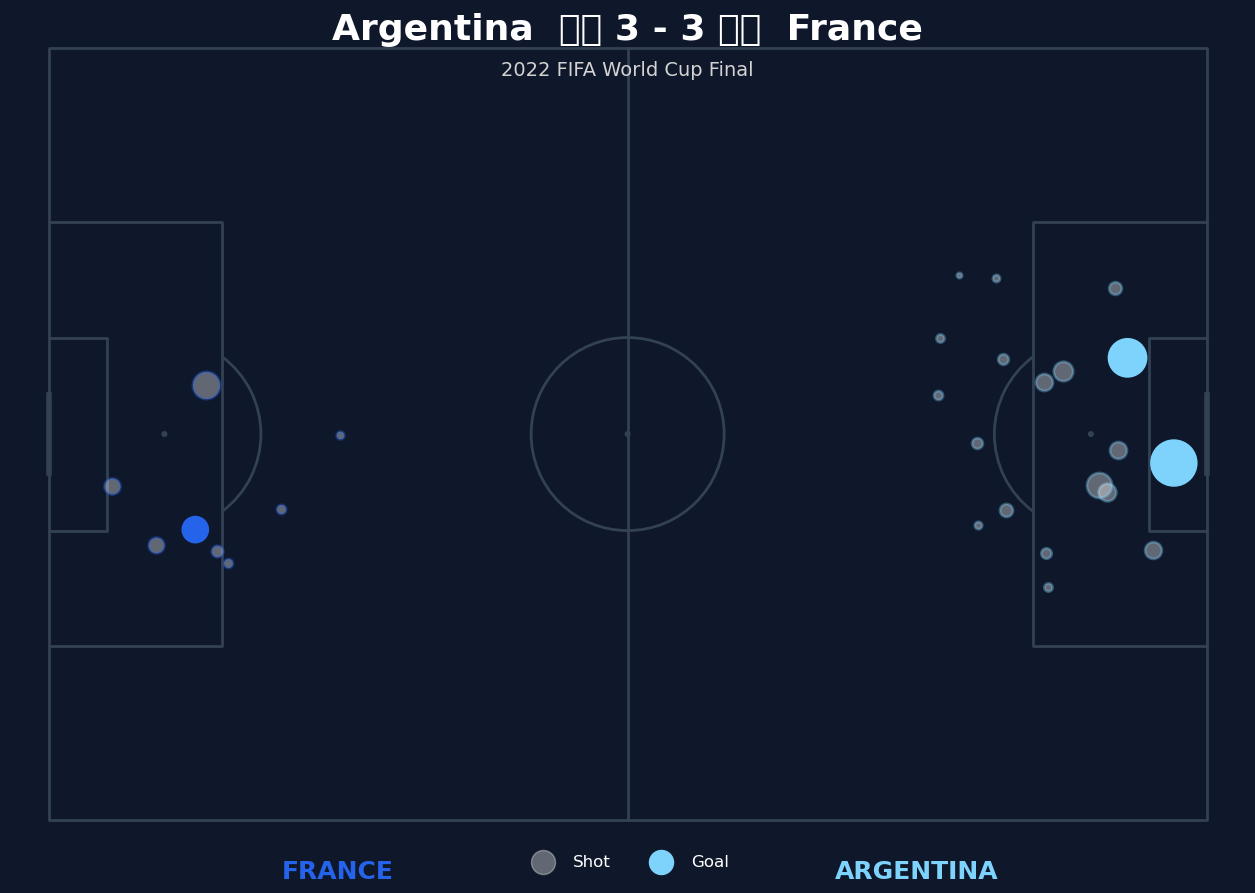

In [18]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Colors
PITCH = "#0F172A"
LINE = "#334155"

ARG = "#7DD3FC"
FRA = "#2563EB"

fig, ax = plt.subplots(figsize=(14, 9), facecolor=PITCH)

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color=PITCH,
    line_color=LINE,
    linewidth=2
)

pitch.draw(ax=ax)

for shot in df.to_dict(orient="records"):

    if shot["team"] == "France":

        x = 120 - shot["x"]
        y = 80 - shot["y"]

        color = FRA if shot["shot_outcome"] == "Goal" else "white"
        alpha = 1 if shot["shot_outcome"] == "Goal" else 0.35

        sc = pitch.scatter(
            x=x,
            y=y,
            s=1400 * shot["shot_statsbomb_xg"],
            c=color,
            ec=FRA,
            lw=2,
            alpha=alpha,
            ax=ax,
            zorder=3
        )

        if shot["shot_outcome"] == "Goal":
            sc.set_path_effects([
                pe.withStroke(linewidth=8, foreground=FRA)
            ])

    else:

        color = ARG if shot["shot_outcome"] == "Goal" else "white"
        alpha = 1 if shot["shot_outcome"] == "Goal" else 0.35

        sc = pitch.scatter(
            x=shot["x"],
            y=shot["y"],
            s=1400 * shot["shot_statsbomb_xg"],
            c=color,
            ec=ARG,
            lw=2,
            alpha=alpha,
            ax=ax,
            zorder=3
        )

        if shot["shot_outcome"] == "Goal":
            sc.set_path_effects([
                pe.withStroke(linewidth=8, foreground=ARG)
            ])

# -----------------------------
# Header
# -----------------------------

fig.text(
    0.5,
    0.95,
    "Argentina  🇦🇷 3 - 3 🇫🇷  France",
    ha="center",
    color="white",
    fontsize=26,
    fontweight="bold"
)

fig.text(
    0.5,
    0.91,
    "2022 FIFA World Cup Final",
    ha="center",
    color="lightgray",
    fontsize=14
)

# Team Labels
ax.text(
    30,
    86,
    "FRANCE",
    color=FRA,
    fontsize=18,
    fontweight="bold",
    ha="center"
)

ax.text(
    90,
    86,
    "ARGENTINA",
    color=ARG,
    fontsize=18,
    fontweight="bold",
    ha="center"
)

# Legend
ax.scatter([], [], s=300, c='white', alpha=0.35, label='Shot')
ax.scatter([], [], s=300, c=ARG, label='Goal')

leg = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False,
    fontsize=12
)

for text in leg.get_texts():
    text.set_color("white")

ax.set_axis_off()

plt.tight_layout()
plt.show()